## Modeling for predicting hospitalization at ED disposition

Work Flow:
1. Task-specific filter
2. Variable selection
3. Modeling script
4. Performance output


### Load train and test

In [1]:
##USE PYTHON3.10-Rich1.0 KERNEL
import os
import time
import random
import tensorflow as tf
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import optimizers, metrics
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.layers import concatenate
from tensorflow.keras.models import load_model
from helpers import PlotROCCurve, get_lstm_data_gen
from dataset_path import output_path

df_train = pd.read_csv('mv_train_DISPOSITION.csv')
df_test = pd.read_csv('mv_test_DISPOSITION.csv')
df_val = pd.read_csv("mv_val_DISPOSITION.csv")
confidence_interval = 95
random_seed=0

2026-04-06 17:22:00.913792: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-06 17:22:00.945899: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-06 17:22:00.945926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-06 17:22:00.947429: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-06 17:22:00.953818: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-06 17:22:00.954611: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
random.seed(random_seed)
np.random.seed(random_seed)

In [3]:
pd.set_option('display.max_columns', 100) 
pd.set_option('display.max_rows', 100) 

df_train.head()

,index,subject_id,hadm_id,stay_id,intime,outtime,anchor_age,gender,anchor_year,dod,admittime,dischtime,deathtime,ethnicity,edregtime,edouttime,insurance,in_year,age,outcome_inhospital_mortality,ed_death,before_ed_mortality,ed_los,intime_icu,time_to_icu_transfer,outcome_icu_transfer_12h,outcome_hospitalization,outcome_critical,n_ed_30d,n_ed_90d,n_ed_365d,next_ed_visit_time,next_ed_visit_time_diff,outcome_ed_revisit_3d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,ed_los_hours,time_to_icu_transfer_hours,next_ed_visit_time_diff_days,triage_temperature,triage_heartrate,triage_resprate,triage_o2sat,triage_sbp,triage_dbp,triage_pain,...,eci_CHF,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_PVD,eci_HTN1,eci_HTN2,eci_Paralysis,eci_NeuroOther,eci_Pulmonary,eci_DM1,eci_DM2,eci_Hypothyroid,eci_Renal,eci_Liver,eci_PUD,eci_HIV,eci_Lymphoma,eci_Tumor2,eci_Tumor1,eci_Rheumatic,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression,ed_temperature_last,ed_heartrate_last,ed_resprate_last,ed_o2sat_last,ed_sbp_last,ed_dbp_last,ed_pain_last,n_med,n_medrecon,triage_MAP,score_CCI,score_CART,score_REMS,score_NEWS,score_NEWS2,score_MEWS,split,notes,ecg_paths
0,17625,13109623,NaN,34225339,2140-04-07 14:05:00,2140-04-07 14:24:00,63,F,2137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2140,66,False,False,False,0 days 00:19:00,NaN,NaN,False,False,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,0.32,NaN,NaN,36.055556,69.000000,16.000000,98.000000,116.000000,77.000000,6.000000,...,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,36.777778,58.0,18.0,98.0,138.0,83.0,5.0,5.0,8.0,90.000000,4,4,7,0,0,1,train,female with pmhx of copd presents with worseni...,['files/p1310/p13109623/s42270583/42270583']
1,2551,10455855,28782492.0,39040844,2173-05-23 15:30:00,2173-05-24 14:15:00,83,F,2168,NaN,2173-05-23 23:27:00,2173-05-24 14:15:00,NaN,BLACK/AFRICAN AMERICAN,2173-05-23 15:30:00,2173-05-24 14:15:00,Medicare,2173,88,False,False,False,0 days 22:45:00,NaN,NaN,False,True,False,1,3,6,2173-10-09 16:37:00,138 days 02:22:00,False,1,3,6,0,0,0,22.75,NaN,138.1,36.712811,88.000000,20.000000,99.000000,136.000000,72.000000,8.000000,...,1,1,1,1,1,1,1,0,1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,36.833333,67.0,16.0,100.0,158.0,66.0,0.0,6.0,21.0,93.333333,13,9,6,0,0,1,train,hx dm cad dddr pacer htn pvd ckd and other med...,['files/p1045/p10455855/s42219625/42219625']
2,206075,16957065,20359481.0,31366838,2141-05-15 12:48:00,2141-05-15 14:33:48,45,M,2141,NaN,2141-05-15 14:33:00,2141-05-17 11:28:00,NaN,BLACK/AFRICAN AMERICAN,2141-05-15 12:48:00,2141-05-16 16:06:00,Other,2141,45,False,False,False,0 days 01:45:48,NaN,NaN,False,True,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,1.76,NaN,NaN,36.712811,85.085489,17.554838,98.374259,134.906695,77.480026,4.167576,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.666667,76.0,16.0,99.0,116.0,88.0,0.0,12.0,1.0,96.622249,0,0,2,0,0,1,train,exam chest single ap upright portable view cli...,['files/p1695/p16957065/s42159886/42159886']
3,286106,11250014,28672115.0,33227506,2153-12-15 19:16:00,2153-12-16 02:45:00,66,M,2153,NaN,2153-12-16 01:03:00,2153-12-22 15:15:00,NaN,WHITE,2153-12-15 19:16:00,2153-12-16 02:45:00,Medicare,2153,66,False,False,False,0 days 07:29:00,NaN,NaN,False,True,False,0,0,0,NaN,NaN,False,0,0,0,0,0,0,7.48,NaN,NaN,37.388889,90.000000,18.000000,95.000000,143.000000,78.000000,8.000000,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,36.666667,73.0,17.0,95.0,161.0,71.0,3.0,1.0,0.0,99.666667,2,4,5,1,0,1,train,examination pelvis w judet views 3v indication...,['files/p1125/p11250014/s40838501/40838501']
4,175768,11575157,23296236.0,34870767,2209-06-01 15:54:00,2209-06-02 03:26:00,63,F,2201,NaN,2209-06-02 01:09:00,2209-06-05 17:00:00,NaN,BLACK/AFRICAN AMERICAN,2209-06-01 15:54:00,2209-06-02 03:26:00,Medicare,2209,71,False,False,False,0 days 11:32:00,NaN,NaN,False,True,False,0,0,2,2209-09-08 13:03:00,98 days 09:37:00,False,0

### 1. task-specific filter: No specific filtering needed

In [4]:
print('training size =', len(df_train), ', testing size =', len(df_test))

training size = 151886 , testing size = 18986


### 2. Variable Selection

In [5]:
variable = ["age", "gender", 
            
            "n_ed_30d", "n_ed_90d", "n_ed_365d", "n_hosp_30d", "n_hosp_90d", 
            "n_hosp_365d", "n_icu_30d", "n_icu_90d", "n_icu_365d", 
            
            "triage_pain", "triage_acuity",
            
            "chiefcom_chest_pain", "chiefcom_abdominal_pain", "chiefcom_headache", 
            "chiefcom_shortness_of_breath", "chiefcom_back_pain", "chiefcom_cough", 
            "chiefcom_nausea_vomiting", "chiefcom_fever_chills", "chiefcom_syncope",
            "chiefcom_dizziness",
            
            "cci_MI", "cci_CHF", "cci_PVD", "cci_Stroke", "cci_Dementia", "cci_Pulmonary", 
            "cci_Rheumatic", "cci_PUD", "cci_Liver1", "cci_DM1", "cci_DM2", 
            "cci_Paralysis", "cci_Renal", "cci_Cancer1", "cci_Liver2", "cci_Cancer2", 
            "cci_HIV",
            
            "eci_Arrhythmia", "eci_Valvular", "eci_PHTN",  "eci_HTN1", "eci_HTN2",  
            "eci_NeuroOther", "eci_Hypothyroid", "eci_Lymphoma", "eci_Coagulopathy", 
            "eci_Obesity", "eci_WeightLoss", "eci_FluidsLytes", "eci_BloodLoss", 
            "eci_Anemia", "eci_Alcohol", "eci_Drugs", "eci_Psychoses", "eci_Depression",
            
            "ed_temperature_last", "ed_heartrate_last", "ed_resprate_last", 
            "ed_o2sat_last", "ed_sbp_last", "ed_dbp_last", "ed_los", "n_med", "n_medrecon"]

outcome = "outcome_hospitalization"

In [6]:
X_train = df_train[variable].copy()
y_train = df_train[outcome].copy()
X_test = df_test[variable].copy()
y_test = df_test[outcome].copy()
X_val = df_val[variable].copy()
y_val = df_val[outcome].copy()

In [7]:
X_train.dtypes.to_frame().T

,age,gender,n_ed_30d,n_ed_90d,n_ed_365d,n_hosp_30d,n_hosp_90d,n_hosp_365d,n_icu_30d,n_icu_90d,n_icu_365d,triage_pain,triage_acuity,chiefcom_chest_pain,chiefcom_abdominal_pain,chiefcom_headache,chiefcom_shortness_of_breath,chiefcom_back_pain,chiefcom_cough,chiefcom_nausea_vomiting,chiefcom_fever_chills,chiefcom_syncope,chiefcom_dizziness,cci_MI,cci_CHF,cci_PVD,cci_Stroke,cci_Dementia,cci_Pulmonary,cci_Rheumatic,cci_PUD,cci_Liver1,cci_DM1,cci_DM2,cci_Paralysis,cci_Renal,cci_Cancer1,cci_Liver2,cci_Cancer2,cci_HIV,eci_Arrhythmia,eci_Valvular,eci_PHTN,eci_HTN1,eci_HTN2,eci_NeuroOther,eci_Hypothyroid,eci_Lymphoma,eci_Coagulopathy,eci_Obesity,eci_WeightLoss,eci_FluidsLytes,eci_BloodLoss,eci_Anemia,eci_Alcohol,eci_Drugs,eci_Psychoses,eci_Depression,ed_temperature_last,ed_heartrate_last,ed_resprate_last,ed_o2sat_last,ed_sbp_last,ed_dbp_last,ed_los,n_med,n_medrecon
0,int64,object,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,object,float64,float64


In [8]:
encoder = LabelEncoder()
X_train['gender'] = encoder.fit_transform(X_train['gender'])
X_test['gender'] = encoder.transform(X_test['gender'])
X_val['gender'] = encoder.transform(X_val['gender'])

In [9]:
X_train['ed_los'] = pd.to_timedelta(X_train['ed_los']).dt.seconds / 60
X_test['ed_los'] = pd.to_timedelta(X_test['ed_los']).dt.seconds / 60
X_val['ed_los'] = pd.to_timedelta(X_val['ed_los']).dt.seconds / 60

In [10]:
print('class ratio')
print('positiave : negative =', y_train.sum()/(~y_train).sum(), ': 1')

class ratio
positiave : negative = 2.0878041838622456 : 1


### 3.  Modeling script

In [11]:
# Containers for all results
result_list = []

Logistic Regression:


/opt/python-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training time: 5.077552318572998 seconds
AUC: 0.9976362717382181
AUPRC: 0.9989205502401899
Sensitivity: 0.9787649309079554
Specificity: 0.9838109114456856
Score thresold: 0.6126375112898502
2.5 97.5


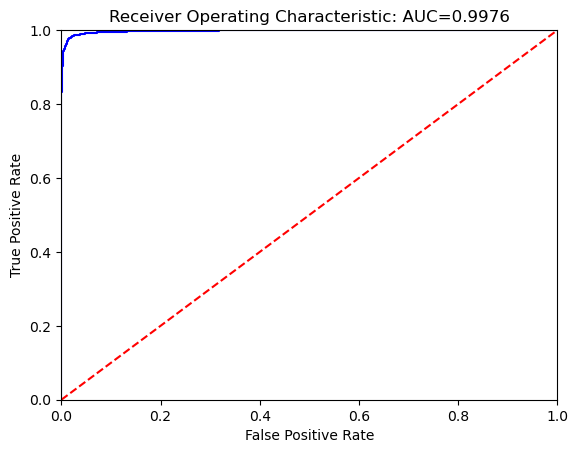

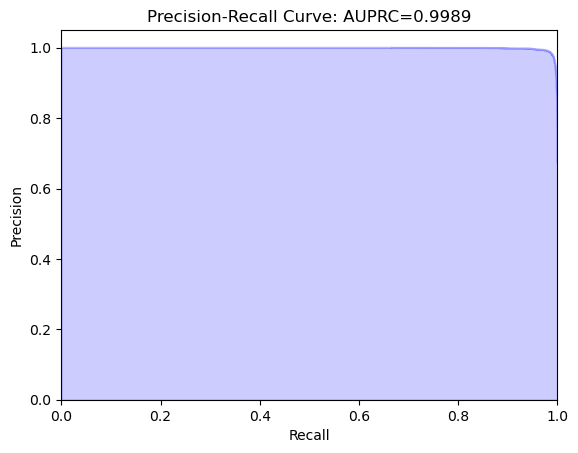

In [12]:
print("Logistic Regression:")
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(random_state=random_seed)
start = time.time()
logreg.fit(X_train,y_train)
runtime = time.time()-start
import pickle
with open('task4_logreg.pickle', 'wb') as model_dump:
    pickle.dump(logreg, model_dump)
print('Training time:', runtime, 'seconds')
probs = logreg.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["LR"]
results.extend(result)
results.append(runtime)
result_list.append(results)



RandomForest:
Training time: 19.681832551956177 seconds
AUC: 0.9958527420080736
AUPRC: 0.99738786325303
Sensitivity: 0.9789991412288235
Specificity: 0.985267929415574
Score thresold: 0.67
2.5 97.5


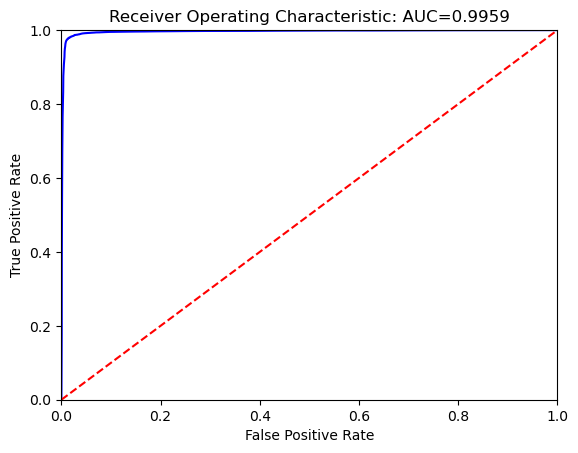

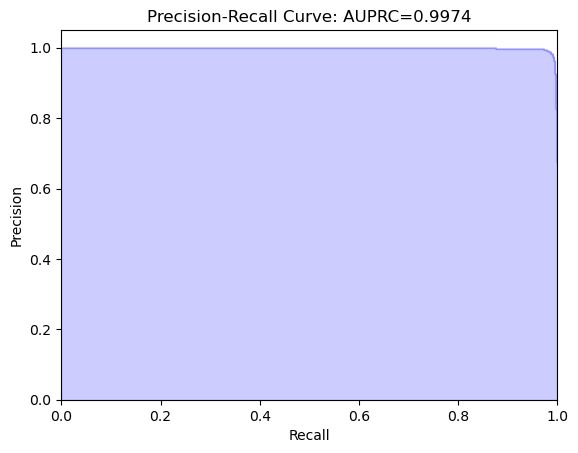

[1.73862532e-02 3.32186576e-03 1.53610540e-03 2.31245722e-03
 4.64230121e-03 2.16110039e-03 5.08342653e-03 5.46885076e-03
 3.43501804e-04 5.87490557e-04 1.91436064e-03 1.43852407e-02
 4.83023988e-02 1.62709054e-03 1.31612133e-03 1.87198954e-03
 1.38751312e-04 9.33621603e-04 7.19319370e-04 5.91598663e-04
 9.16530223e-04 5.84143681e-04 7.89175364e-04 8.20636904e-04
 1.56411885e-03 8.52317532e-04 7.91807975e-04 4.33630231e-04
 1.34871544e-03 5.23162339e-04 3.73310661e-04 9.73870628e-04
 1.29427354e-03 8.34920100e-04 3.24162128e-04 1.66271799e-03
 9.31486415e-04 5.30315384e-04 5.36634528e-04 2.66782570e-04
 1.48116984e-03 8.03710999e-04 7.57804080e-04 1.70452853e-03
 1.63970029e-03 1.00787659e-03 9.79263153e-04 3.55988015e-04
 1.23967953e-03 1.11988293e-03 8.39805449e-04 2.76530769e-03
 3.26901449e-04 7.99414527e-04 8.96409349e-04 8.42218344e-04
 5.53598039e-04 1.31284891e-03 1.01317193e-02 1.40686605e-02
 1.42327944e-02 8.54106717e-03 1.15315016e-02 1.74053267e-02
 7.09350090e-01 5.572418

In [13]:
print("RandomForest:")
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(random_state=random_seed)
start = time.time()
rf.fit(X_train,y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
probs = rf.predict_proba(X_test)
result = PlotROCCurve(probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)
importances = rf.feature_importances_
print(importances)

results = ["RF"]
results.extend(result)
results.append(runtime)
result_list.append(results)

GradientBoosting:
Training time: 34.92669367790222 seconds
AUC: 0.9978047474587497
AUPRC: 0.9990002260930166
Sensitivity: 0.9796237020844718
Specificity: 0.9841346932167719
Score thresold: 0.6832122075684127
2.5 97.5


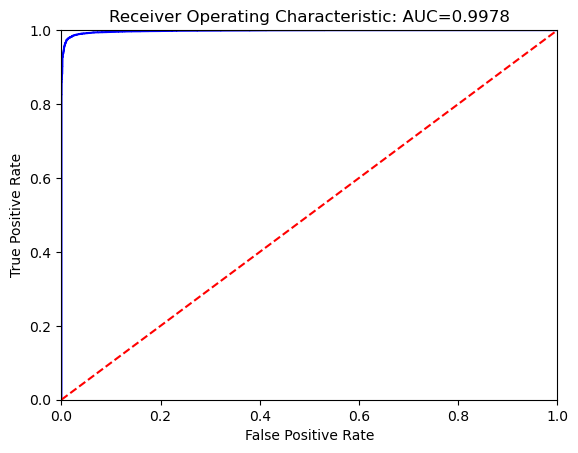

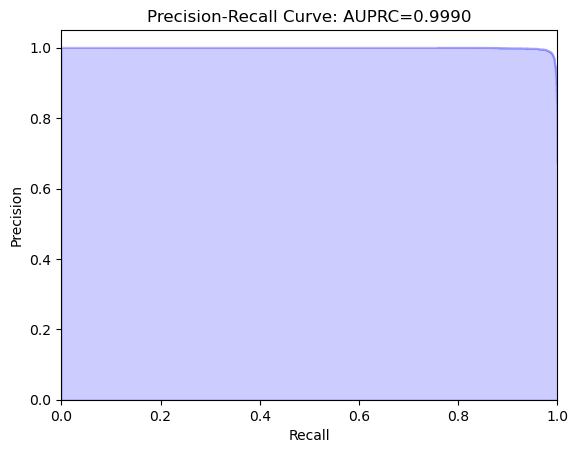

In [14]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
test_probs = gb.predict_proba(X_test)
result = PlotROCCurve(test_probs[:,1],y_test, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [15]:
import pandas as pd
import numpy as np

test_probs = test_probs[:,1]

test_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_test)),   # replace with real ID if available
    "y_true": y_test,
    "pred_prob_structured": test_probs
})

test_pred_df["y_true"] = test_pred_df["y_true"].astype(int)
test_pred_df.to_csv("structured_test_predictions_task5.csv", index=False)

test_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,1,0.997239
1,1,0,0.003398
2,2,1,0.999156
3,3,1,0.998999
4,4,0,0.004526


GradientBoosting:
Training time: 35.1381950378418 seconds
AUC: 0.9981250606024424
AUPRC: 0.9991339237091343
Sensitivity: 0.9820718684231039
Specificity: 0.9848952411888907
Score thresold: 0.6899135314502489
2.5 97.5


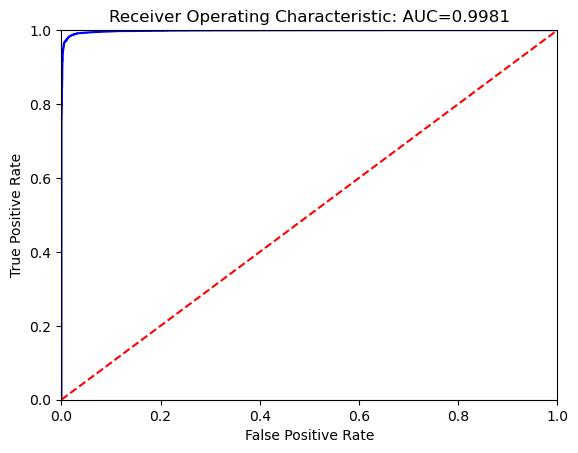

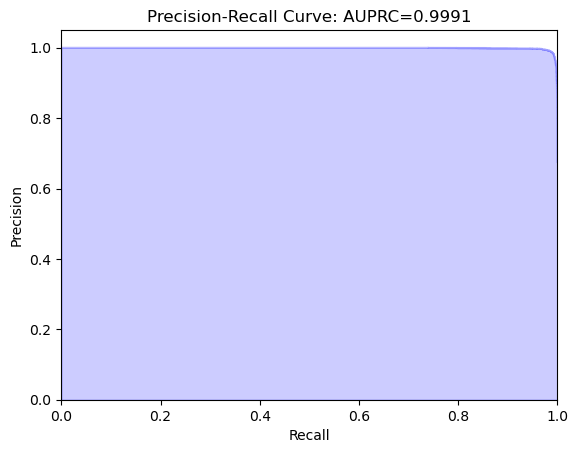

In [16]:
print("GradientBoosting:")
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=random_seed)
start = time.time()
gb.fit(X_train, y_train)
runtime = time.time()-start
print('Training time:', runtime, 'seconds')
val_probs = gb.predict_proba(X_val)
result = PlotROCCurve(val_probs[:,1],y_val, ci=confidence_interval, random_seed=random_seed)

results = ["GB"]
results.extend(result)
results.append(runtime)
result_list.append(results)

In [17]:
import pandas as pd
import numpy as np

val_probs = val_probs[:,1]

val_pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_val)),   # replace with real ID if available
    "y_true": y_val,
    "pred_prob_structured": val_probs
})

val_pred_df["y_true"] = val_pred_df["y_true"].astype(int)
val_pred_df.to_csv("structured_val_predictions_task5.csv", index=False)

val_pred_df.head()

,sample_id,y_true,pred_prob_structured
0,0,1,0.999043
1,1,1,0.998963
2,2,1,0.999180
3,3,1,0.895403
4,4,1,0.994455


In [18]:
class MLP(tf.keras.Model):
    def __init__(self):
        super(MLP, self).__init__()
        self.dense_1 = Dense(128, activation='relu')
        self.dense_2 = Dense(64, activation='relu')
        self.classifier = Dense(1, activation='sigmoid')

    def call(self, x):
        x = self.dense_1(x)
        x = self.dense_2(x)
        return self.classifier(x)

Epoch 1/20


2026-04-06 17:23:51.504557: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: agc07
2026-04-06 17:23:51.504585: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: agc07
2026-04-06 17:23:51.504880: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2026-04-06 17:23:51.504924: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 580.126.20


760/760 [==============================] - 2s 2ms/step - loss: 0.0815 - accuracy: 0.9792 - auc: 0.9940 - auprc: 0.9960 - tp: 101016.0000 - tn: 47717.0000 - precision: 0.9856 - recall: 0.9836
Epoch 2/20
760/760 [==============================] - 1s 2ms/step - loss: 0.0538 - accuracy: 0.9821 - auc: 0.9969 - auprc: 0.9982 - tp: 101199.0000 - tn: 47968.0000 - precision: 0.9881 - recall: 0.9854
Epoch 3/20
760/760 [==============================] - 2s 2ms/step - loss: 0.0523 - accuracy: 0.9821 - auc: 0.9971 - auprc: 0.9984 - tp: 101195.0000 - tn: 47971.0000 - precision: 0.9881 - recall: 0.9854
Epoch 4/20
760/760 [==============================] - 1s 2ms/step - loss: 0.0509 - accuracy: 0.9825 - auc: 0.9973 - auprc: 0.9985 - tp: 101195.0000 - tn: 48034.0000 - precision: 0.9887 - recall: 0.9854
Epoch 5/20
760/760 [==============================] - 2s 2ms/step - loss: 0.0503 - accuracy: 0.9828 - auc: 0.9973 - auprc: 0.9985 - tp: 101251.0000 - tn: 48024.0000 - precision: 0.9886 - recall: 0.9859
E

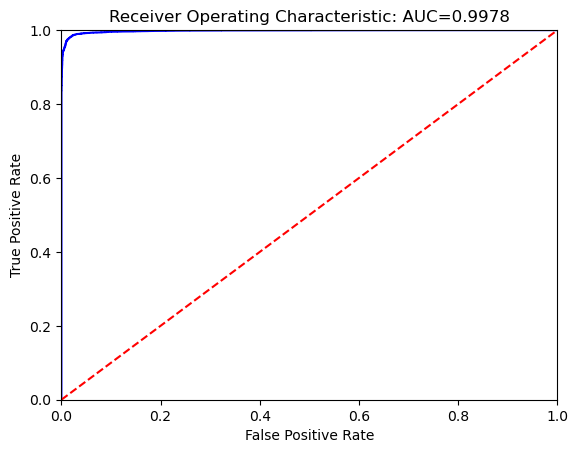

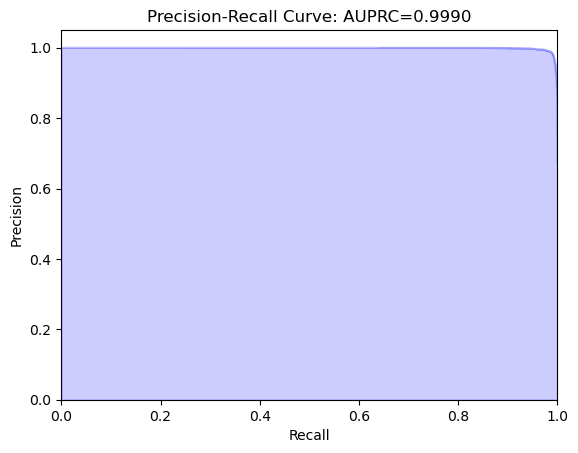

In [19]:
mlp = MLP()
mlp.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=[
        'accuracy',
        metrics.AUC(name='auc'),
        metrics.AUC(name='auprc', curve='PR'),
        metrics.TruePositives(name='tp'),
        metrics.TrueNegatives(name='tn'),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
    ]
)

start = time.time()
mlp.fit(X_train.astype(np.float32), y_train, batch_size=200, epochs=20)
runtime = time.time() - start
print('Training time:', runtime, 'seconds')

mlp.save('hospitalization_disposition_mlp_MV.keras')

print("MLP:")
probs = mlp.predict(X_test.astype(np.float32))
result = PlotROCCurve(probs, y_test, ci=confidence_interval, random_seed=random_seed)

results = ["MLP"]
results.extend(result)
results.append(runtime)
result_list.append(results)